In [1]:
!pip install yfinance pandas matplotlib scipy

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.5 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.0
    Uninstalling cffi-1.17.0:
      Successfully uninstalled cffi-1.17.0


In [2]:
import yfinance as yf
import pandas as pd

# 1. Define the stock tickers we want to analyze
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN"]

# 2. Download the data from Yahoo Finance (we only grab the 'Close' prices)
print("Downloading stock data...")
data = yf.download(stocks, start="2020-01-01", end="2025-01-01")["Close"]

# 3. Look at the first 5 rows of our data table
data.head()

[*********************100%***********************]  3 of 4 completed
[**********************75%***********            ]  3 of 4 completed

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,72.333878,94.900497,67.832504,151.829483
2020-01-03,71.630646,93.748497,67.477669,149.938995
2020-01-06,72.201416,95.143997,69.276215,150.326614
2020-01-07,71.861855,95.343002,69.142403,148.955933
2020-01-08,73.017845,94.598503,69.634544,151.328568


In [3]:
# Calculate the percentage change from the previous day
returns = data.pct_change().dropna()

# Look at the first 5 rows of our returns
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012451
2020-01-06,0.007968,0.014886,0.026654,0.002585
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118
2020-01-08,0.016086,-0.007809,0.007118,0.015928
2020-01-09,0.021241,0.004799,0.010498,0.012493


In [4]:
# 1. Calculate the average daily return for each stock
mean_daily_returns = returns.mean()

# 2. Annualize it by multiplying by 252 trading days
annual_returns = mean_daily_returns * 252

print("--- Annualized Returns ---")
print(annual_returns)

--- Annualized Returns ---
Ticker
AAPL     0.297892
AMZN     0.232658
GOOGL    0.257608
MSFT     0.248931
dtype: float64


In [5]:
# Calculate the annualized covariance matrix
cov_matrix = returns.cov() * 252

print("--- Annualized Covariance Matrix ---")
cov_matrix

--- Annualized Covariance Matrix ---


Ticker,AAPL,AMZN,GOOGL,MSFT
Ticker,,,,
AAPL,0.100354,0.067469,0.066809,0.072297
AMZN,0.067469,0.129341,0.075643,0.074418
GOOGL,0.066809,0.075643,0.105618,0.073956
MSFT,0.072297,0.074418,0.073956,0.093008


In [6]:
import numpy as np

def portfolio_return(weights, annual_returns):
    # This multiplies each stock's weight by its return, and adds them up
    return np.sum(weights * annual_returns)

# TEST IT: Let's pretend we put 25% of our money into each of the 4 stocks
test_weights = np.array([0.25, 0.25, 0.25, 0.25])

test_return = portfolio_return(test_weights, annual_returns)
print(f"Equal-Weight Portfolio Return: {test_return:.4f} (or {test_return*100:.2f}%)")

Equal-Weight Portfolio Return: 0.2593 (or 25.93%)


In [7]:
def portfolio_volatility(weights, cov_matrix):
    # This is the Python code for the math formula: square root of (w^T * Cov * w)
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# TEST IT: Calculate the risk for our equal-weight portfolio
test_vol = portfolio_volatility(test_weights, cov_matrix)
print(f"Equal-Weight Portfolio Volatility: {test_vol:.4f} (or {test_vol*100:.2f}%)")

Equal-Weight Portfolio Volatility: 0.2839 (or 28.39%)


In [8]:
def sharpe_ratio(weights, annual_returns, cov_matrix, risk_free_rate=0.03):
    ret = portfolio_return(weights, annual_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    
    # Calculate risk-adjusted return
    return (ret - risk_free_rate) / vol

# TEST IT: Calculate the Sharpe Ratio for our equal-weight portfolio
test_sharpe = sharpe_ratio(test_weights, annual_returns, cov_matrix)
print(f"Equal-Weight Portfolio Sharpe Ratio: {test_sharpe:.4f}")

Equal-Weight Portfolio Sharpe Ratio: 0.8076


In [9]:
# Set the number of portfolios to simulate
num_portfolios = 10000

# Create an empty list to store our results
results = []
all_weights = []

for _ in range(num_portfolios):
    # 1. Generate 4 random numbers for our weights
    weights = np.random.random(len(stocks))
    # 2. Scale them so they add up to exactly 1.0 (100% of our money)
    weights /= np.sum(weights)
    
    # Save the weights for later
    all_weights.append(weights)
    
    # 3. Calculate metrics using the functions we wrote earlier
    ret = portfolio_return(weights, annual_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    sharpe = (ret - 0.03) / vol # using 0.03 as risk-free rate
    
    # Store the results
    results.append([ret, vol, sharpe])

# Convert our results list into a clean Pandas table (DataFrame)
portfolios_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])

print("Simulation complete! Generated 10,000 unique portfolios.")
portfolios_df.head()

Simulation complete! Generated 10,000 unique portfolios.


,Return,Volatility,Sharpe
0,0.254709,0.285249,0.787764
1,0.250282,0.291388,0.755974
2,0.266298,0.283510,0.833471
3,0.257903,0.288551,0.789818
4,0.263838,0.282948,0.826435


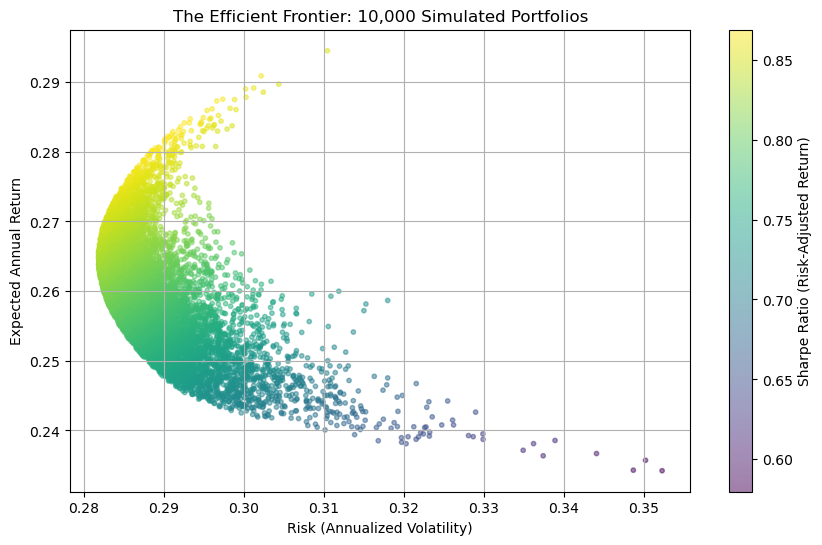

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# We changed 'markersize=10' to 's=10'
scatter = plt.scatter(
    portfolios_df["Volatility"], 
    portfolios_df["Return"], 
    c=portfolios_df["Sharpe"], 
    cmap="viridis", 
    s=10, 
    alpha=0.5
)

# Add the color bar on the right
plt.colorbar(scatter, label="Sharpe Ratio (Risk-Adjusted Return)")

# Label our axes and title
plt.xlabel("Risk (Annualized Volatility)")
plt.ylabel("Expected Annual Return")
plt.title("The Efficient Frontier: 10,000 Simulated Portfolios")
plt.grid(True)

plt.show()

In [12]:
from scipy.optimize import minimize

# 1. The objective function for Max Sharpe: SciPy can only MINIMIZE things.
# So to find the MAX Sharpe, we tell it to minimize the NEGATIVE Sharpe.
def negative_sharpe(weights):
    return -sharpe_ratio(weights, annual_returns, cov_matrix)

# 2. Constraint: All weights must add up to exactly 1.0 (100% of our money)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# 3. Bounds: Each individual stock weight must be between 0 and 1 (no short selling)
bounds = tuple((0, 1) for _ in range(len(stocks)))

# 4. Initial Guess: Start by guessing an equal split (25% each)
initial_weights = np.ones(len(stocks)) / len(stocks)

print("Optimization rules and constraints successfully set up!")

Optimization rules and constraints successfully set up!


In [13]:
# Run the mathematical optimizer for Maximum Sharpe
opt_sharpe = minimize(
    negative_sharpe, 
    initial_weights, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

# Extract the perfect weights
max_sharpe_weights = opt_sharpe.x

print("--- Maximum Sharpe Portfolio Weights ---")
for stock, weight in zip(stocks, max_sharpe_weights):
    print(f"{stock}: {weight*100:.2f}%")

--- Maximum Sharpe Portfolio Weights ---
AAPL: 69.56%
MSFT: 0.00%
GOOGL: 24.75%
AMZN: 5.69%


In [14]:
# The objective function for Min Volatility: Minimize the portfolio volatility function directly
def portfolio_vol(weights):
    return portfolio_volatility(weights, cov_matrix)

# Run the mathematical optimizer for Minimum Volatility
opt_vol = minimize(
    portfolio_vol, 
    initial_weights, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

# Extract the perfect weights
min_vol_weights = opt_vol.x

print("--- Minimum Volatility Portfolio Weights ---")
for stock, weight in zip(stocks, min_vol_weights):
    print(f"{stock}: {weight*100:.2f}%")

--- Minimum Volatility Portfolio Weights ---
AAPL: 32.47%
MSFT: 12.72%
GOOGL: 23.76%
AMZN: 31.05%


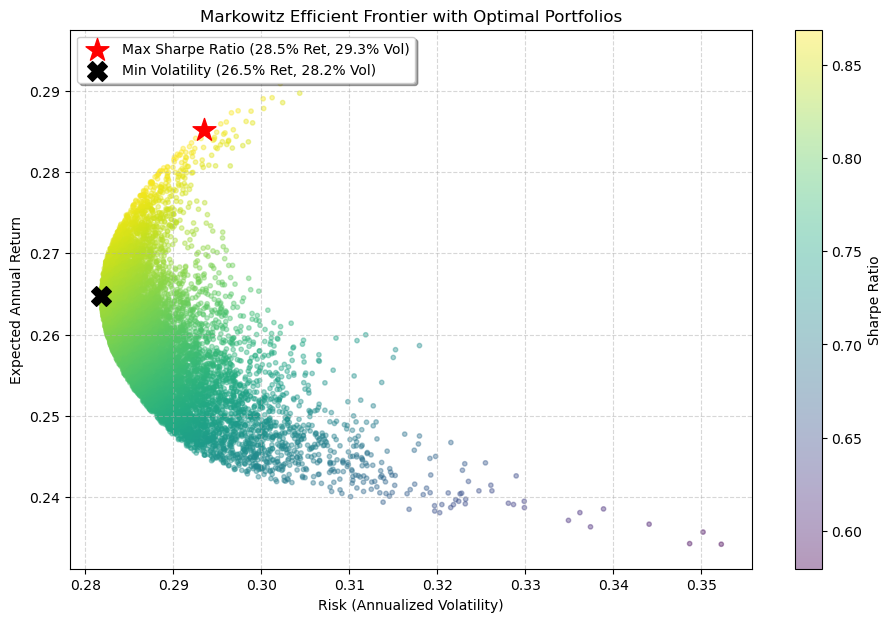

In [15]:
# 1. Calculate final metrics for the Maximum Sharpe Portfolio
max_sharpe_return = portfolio_return(max_sharpe_weights, annual_returns)
max_sharpe_vol = portfolio_volatility(max_sharpe_weights, cov_matrix)

# 2. Calculate final metrics for the Minimum Volatility Portfolio
min_vol_return = portfolio_return(min_vol_weights, annual_returns)
min_vol_vol = portfolio_volatility(min_vol_weights, cov_matrix)

# 3. Create the plot base
plt.figure(figsize=(11, 7))

# Plot the 10,000 simulated portfolios
scatter = plt.scatter(
    portfolios_df["Volatility"], 
    portfolios_df["Return"], 
    c=portfolios_df["Sharpe"], 
    cmap="viridis", 
    s=10, 
    alpha=0.4
)
plt.colorbar(scatter, label="Sharpe Ratio")

# 4. Highlight the Maximum Sharpe Portfolio (Red Star)
plt.scatter(
    max_sharpe_vol, 
    max_sharpe_return, 
    color='red', 
    marker='*', 
    s=300, 
    label=f'Max Sharpe Ratio ({max_sharpe_return*100:.1f}% Ret, {max_sharpe_vol*100:.1f}% Vol)'
)

# 5. Highlight the Minimum Volatility Portfolio (Black X)
plt.scatter(
    min_vol_vol, 
    min_vol_return, 
    color='black', 
    marker='X', 
    s=200, 
    label=f'Min Volatility ({min_vol_return*100:.1f}% Ret, {min_vol_vol*100:.1f}% Vol)'
)

# Labels, Legend, and Layout
plt.xlabel("Risk (Annualized Volatility)")
plt.ylabel("Expected Annual Return")
plt.title("Markowitz Efficient Frontier with Optimal Portfolios")
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [16]:
summary_df = pd.DataFrame({
    'Stock/Metric': stocks + ['Expected Return', 'Annualized Volatility', 'Sharpe Ratio'],
    'Max Sharpe Portfolio': list(np.round(max_sharpe_weights * 100, 2)) + [f"{max_sharpe_return*100:.2f}%", f"{max_sharpe_vol*100:.2f}%", f"{(max_sharpe_return-0.03)/max_sharpe_vol:.2f}"],
    'Min Volatility Portfolio': list(np.round(min_vol_weights * 100, 2)) + [f"{min_vol_return*100:.2f}%", f"{min_vol_vol*100:.2f}%", f"{(min_vol_return-0.03)/min_vol_vol:.2f}"]
})

summary_df

,Stock/Metric,Max Sharpe Portfolio,Min Volatility Portfolio
0,AAPL,69.56,32.47
1,MSFT,0.0,12.72
2,GOOGL,24.75,23.76
3,AMZN,5.69,31.05
4,Expected Return,28.51%,26.48%
5,Annualized Volatility,29.35%,28.18%
6,Sharpe Ratio,0.87,0.83
